In [1]:
import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sdes.plot as splt
from particles.kalman import Kalman
from sdes.cdssm_lib import CDSSM_LIB, build_cdssm
from sdes.continuous_discrete_ssms import NormalCDSSM, MvNormalCDSSM

In [ ]:
run_id = '10'
cdssm_str = 'mv_ou'

df_part_1 = pd.read_json(f'../results/smoothing_exp_run_{run_id}_{cdssm_str}_part_1.json')
df_part_2 = pd.read_json(f'../results/smoothing_exp_run_{run_id}_{cdssm_str}_part_2.json')

with open(f'../results/smoothing_exp_run_{run_id}_{cdssm_str}_meta.pkl', 'rb') as f:
    metadata = dill.load(f)

In [3]:
# Work with copies of the original dfs
df_1 = df_part_1.copy()
df_2 = df_part_2.copy()

# Plot of the CD-SSM

We plot below the simulation of the CD-SSM of interest. We choose a model such that ratio of observation noise/signal noise is high. The smoothing distribution changes materially as the total number of observations increases. 

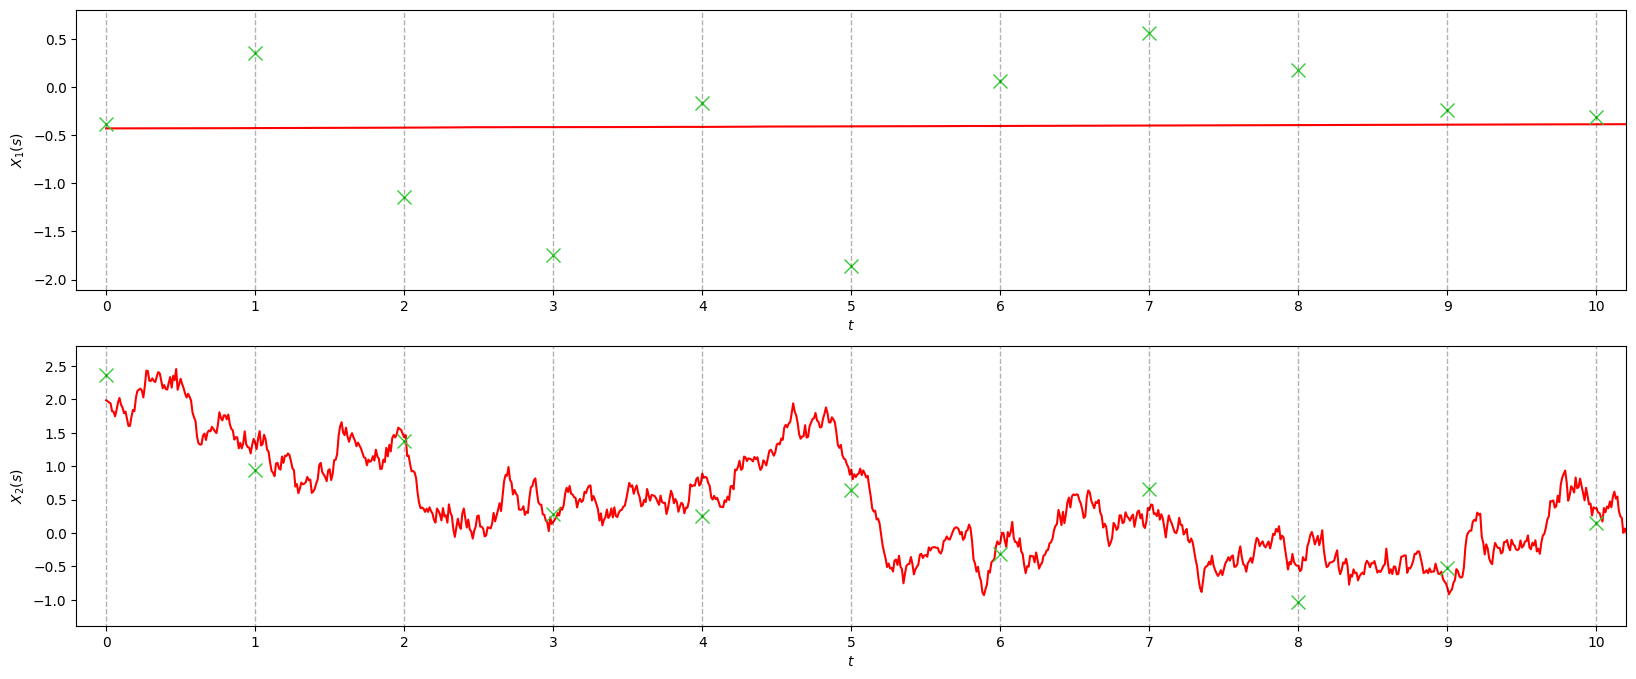

In [4]:
plot_T = 10

cdssm = metadata['cdssm']
x = metadata['x'][:plot_T+2]
y = metadata['y'][:plot_T+2]
Ts = metadata['Ts']
#quantiles = metadata['quantiles']

if isinstance(cdssm, NormalCDSSM): 
    fig, axes = splt.cdssm_simulation_plot(cdssm, x, y)
elif isinstance(cdssm, MvNormalCDSSM):
    fig, axes = splt.mv_cdssm_simulation_plot(cdssm, x, y)
else:
    pass

for ax in axes:
    ax.set_xlim((-0.2, plot_T + 0.2))
plt.show()
# Can add custom changes to the fig/axes below:

# Plot of the true Smoothing Distribution

We choose parameters for the model, such that the smoothing distribution is materially different from the filtering distribution. An illustration of this is presented below, using the true smoothing distributions.

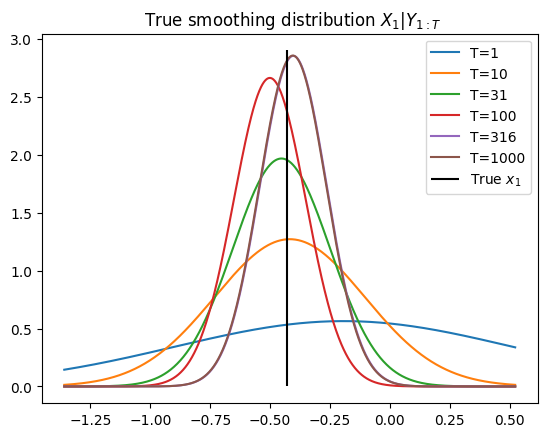

In [5]:
j=1 # Component to plot
x_0_true = metadata['x'][0]['0.0'].ravel() # (dimX, )
fig, ax = plt.subplots()

x_lim_lower = df_1[f'x_0_mean_{j}'][1] - 3. * df_1[f'x_0_std_{j}'][1]
x_lim_upper = df_1[f'x_0_mean_{j}'][1] + 3. * df_1[f'x_0_std_{j}'][1]

x_linsp = np.linspace(x_lim_lower, x_lim_upper, num=1000)

for i in range(df_1.shape[0]):
    y = stats.norm.pdf(x_linsp, loc=df_1[f'x_0_mean_{j}'][i], scale=df_1[f'x_0_std_{j}'][i])
    T = df_1['T'][i]
    ax.plot(x_linsp, y, '-', label=f'T={T}')

plt.vlines(x_0_true[j-1], ymin=0.0, ymax=2.9, colors='black', label=r'True $x_1$')
plt.title(r' True smoothing distribution $X_1 | Y_{1:T}$')
plt.legend()
plt.show()

# Data preprocesing

In [6]:
# Add true quantile values to the true_vals_df (df_1)

dx = metadata['cdssm'].dimX
quantiles = np.linspace(0.05, 0.95, num=19)

for q in quantiles:
    q_str = str(round(q, 2))
    for d in range(cdssm.dimX):
        df_1[f'x_0_q{q_str}_{d+1}'] = df_1[f'x_0_mean_{d+1}'] + stats.norm.ppf(q) * df_1[f'x_0_std_{d+1}']

In [7]:
# Convert estimators of first and second moments to estimators of the std in estimators df (df_2)

df_2 = df_part_2.copy()

for d in range(dx):
    df_2[f'x_0_std_est_{d+1}'] = np.sqrt(df_2[f'x_0_sq_est_{d+1}'] - df_2[f'x_0_est_{d+1}']**2)


In [8]:
df_2

,run_id,seed,method,fk,cpu,x_0_est_1,x_0_sq_est_1,x_0_q0.05_est_1,x_0_q0.1_est_1,x_0_q0.15_est_1,...,x_0_q0.65_est_2,x_0_q0.7_est_2,x_0_q0.75_est_2,x_0_q0.8_est_2,x_0_q0.85_est_2,x_0_q0.9_est_2,x_0_q0.95_est_2,T,x_0_std_est_1,x_0_std_est_2
0,0,23464029,genealogy,bootstrap,0.443412,-0.511204,0.352226,0.039649,0.040143,0.040417,...,0.733537,0.775061,0.804935,0.959653,1.270424,1.589240,1.936211,10,0.301492,0.303611
1,1,73234145,genealogy,bootstrap,0.394304,-0.416615,0.234244,-0.283513,-0.283127,-0.282025,...,0.514384,0.694181,0.878869,1.075316,1.286465,1.510505,1.779663,10,0.246324,0.204480
2,2,128579019,genealogy,bootstrap,0.468119,-0.448161,0.298189,-0.303340,-0.301854,-0.300989,...,0.078811,0.292063,0.605878,0.799057,0.841438,0.973682,1.420443,10,0.311995,0.259851
3,3,164102195,genealogy,bootstrap,0.438115,-0.302104,0.142468,-0.320752,-0.319335,-0.317387,...,0.546045,0.710020,0.861546,0.990094,1.089920,1.247086,1.604943,10,0.226276,0.374729
4,4,200910333,genealogy,bootstrap,0.444651,-0.394188,0.248342,-0.145574,-0.145230,-0.144682,...,0.826554,0.880783,0.939925,1.042187,1.198350,1.390908,1.710851,10,0.304891,0.271853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,95,4102908242,FFBS_MCMC,bootstrap,0.585736,-0.485243,0.235461,-0.286766,-0.162535,-0.089162,...,0.245235,0.340056,0.470861,0.593640,0.748816,0.909804,1.164032,1000,0.000549,0.003435
996,96,4165814912,FFBS_MCMC,bootstrap,0.462620,-0.227885,0.063974,-0.111529,-0.053227,-0.032590,...,0.288345,0.384348,0.503971,0.617217,0.748837,0.921633,1.156193,1000,0.109736,0.231510
997,97,4203071520,FFBS_MCMC,bootstrap,0.450248,-0.518633,0.274358,-0.328480,-0.208910,-0.115270,...,0.284833,0.376791,0.504303,0.618020,0.762820,0.923376,1.110657,1000,0.073334,0.301297
998,98,4228447039,FFBS_MCMC,bootstrap,0.371949,-0.369543,0.141143,-0.267544,-0.167434,-0.117751,...,0.273481,0.365517,0.495680,0.608499,0.757812,0.911691,1.190979,1000,0.067682,0.205728


In [9]:
Ts = df_2['T'].unique().tolist()
methods = df_2['method'].unique().tolist()
groupby = df_2.groupby(['T'])

df_1_T_idx = df_1.set_index('T', inplace=False)

group_dfs = []

for T in Ts:
    group_df = groupby.get_group(T)
    for d in range(dx):
        group_df[f'x_0_est_{d+1}_se'] = (group_df[f'x_0_est_{d+1}'] - df_1_T_idx.loc[T, f'x_0_mean_{d+1}']) ** 2
        group_df[f'x_0_std_est_{d+1}_se'] = (group_df[f'x_0_std_est_{d+1}'] - df_1_T_idx.loc[T,f'x_0_std_{d+1}']) ** 2
        for q in quantiles:
            q_str = str(round(q, 2))
            group_df[f'x_0_q{q_str}_est_{d+1}_se'] = (group_df[f'x_0_q{q_str}_est_{d+1}'] - df_1_T_idx.loc[T, f'x_0_q{q_str}_{d+1}']) ** 2
    group_dfs.append(group_df)

df_2_se = pd.concat(group_dfs, axis=0)

/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_69448/3481808751.py:10: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  group_df = groupby.get_group(T)
/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_69448/3481808751.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df[f'x_0_est_{d+1}_se'] = (group_df[f'x_0_est_{d+1}'] - df_1_T_idx.loc[T, f'x_0_mean_{d+1}']) ** 2
/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_69448/3481808751.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

# Results: CPU Times of the methods

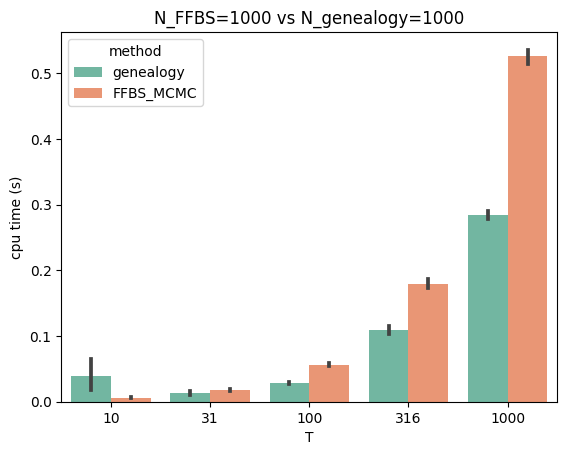

In [10]:
N_FFBS_MCMC = metadata['N_FFBS_MCMC']; N_genealogy = metadata['N_genealogy']
sns.barplot(data=df_part_2, x="T", y="cpu", hue="method", palette="Set2")
fig, ax = plt.gcf(), plt.gca()
plt.ylabel('cpu time (s)')
plt.title(f'N_FFBS={N_FFBS_MCMC} vs N_genealogy={N_genealogy}')
plt.show()

# Results: Estimators of the First and Second Moments

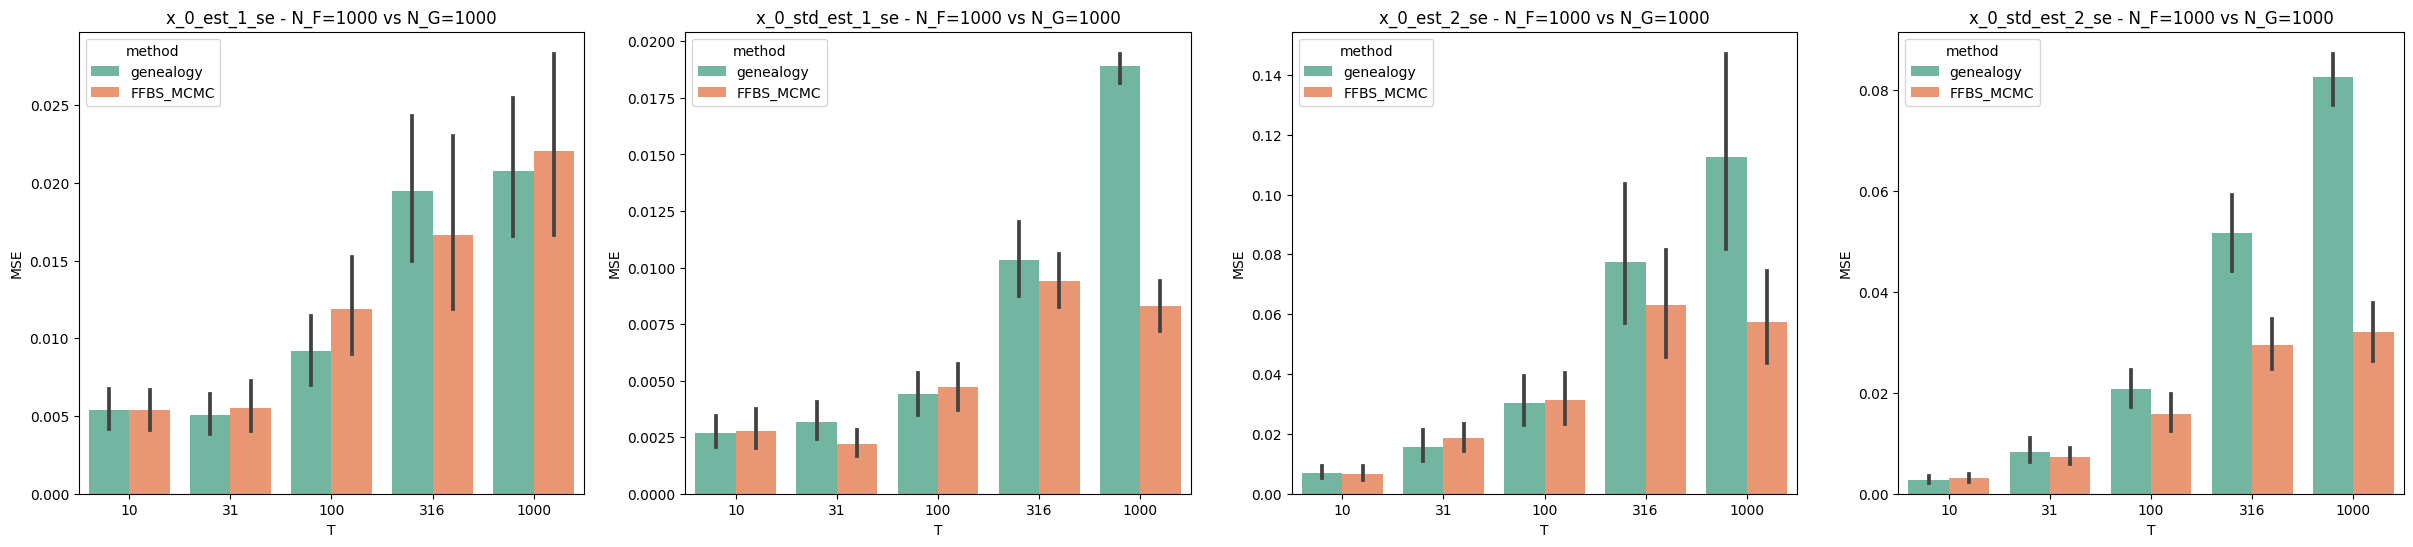

In [18]:
plot_cols = [name for name in df_2_se.columns if ('_se' in name) and ('_q' not in name)]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(30, 6))

for name, ax in zip(plot_cols, axes):
    sns.barplot(data=df_2_se, x="T", y=name, hue="method", ax=ax, palette="Set2")
    ax.set_ylabel('MSE')
    ax.set_title(f'{name} - N_F={N_FFBS_MCMC} vs N_G={N_genealogy}')
plt.show()

# Results: Estimators of Quantiles

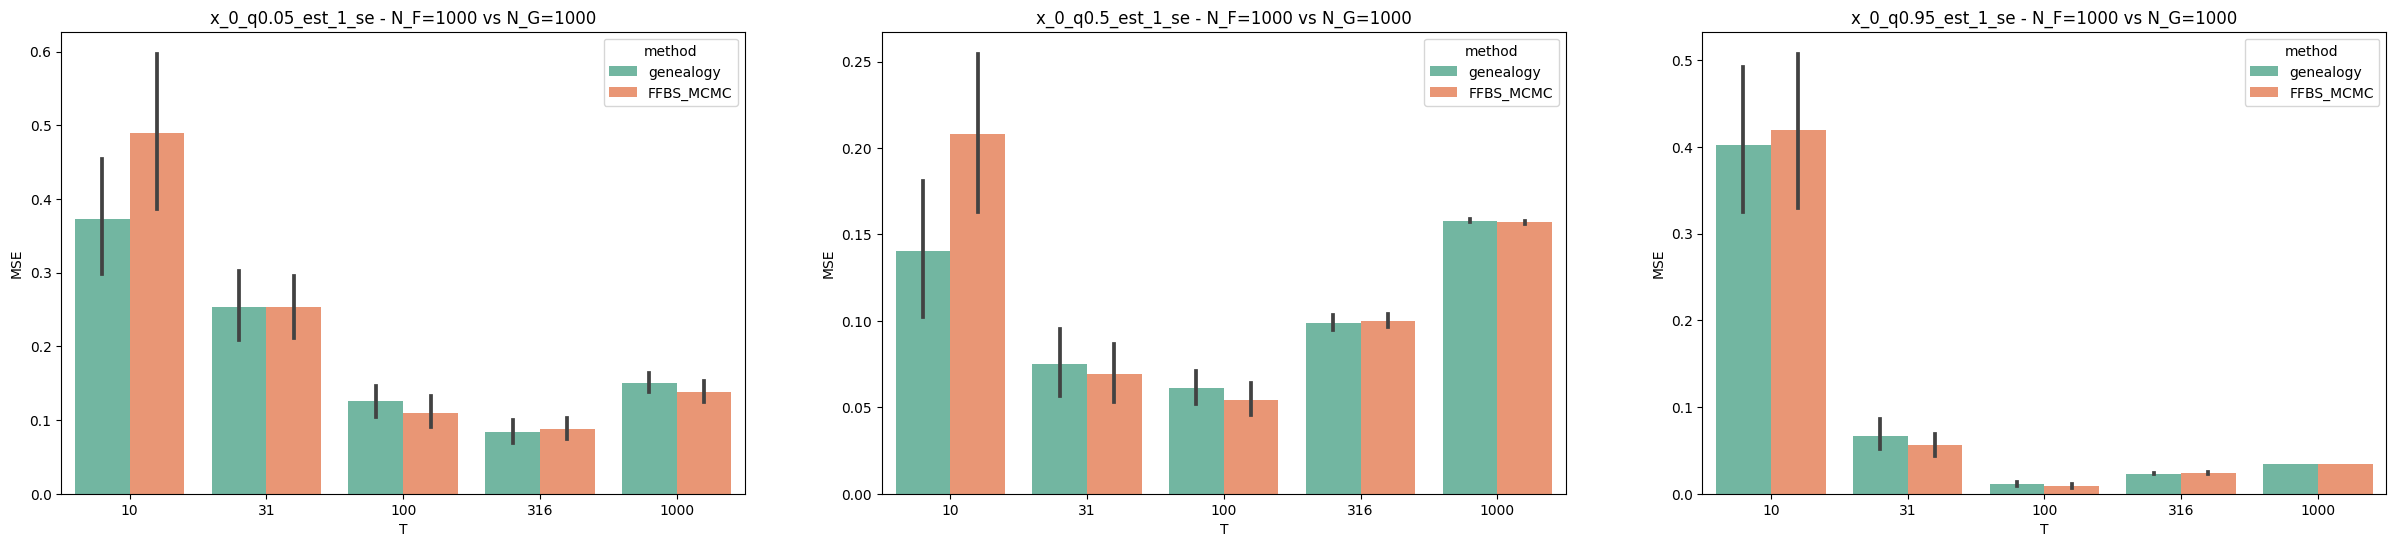

In [21]:
plot_qs = [0.05, 0.5, 0.95]
plot_cols = [f'x_0_q{str(round(q, 2))}_est_1_se' for q in plot_qs]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(30, 6))

for name, ax in zip(plot_cols, axes):
    sns.barplot(data=df_2_se, x="T", y=name, hue="method", ax=ax, palette="Set2")
    ax.set_ylabel('MSE')
    ax.set_title(f'{name} - N_F={N_FFBS_MCMC} vs N_G={N_genealogy}')
plt.show()

In [20]:
plot_cols

['x_0_q0.05_est_1_se', 'x_0_q0.5_est_1_se', 'x_0_q0.95_est_1_se']

# Diagnostic: Run a single particle filter for particle filter used in the experiment, and evaluate the genealogy 

In [94]:
import particles.state_space_models as ssms
from sdes.core import SMC

T = 100

lgssm = metadata['lgssm']
y = metadata['y']

fk = ssms.Bootstrap(ssm=lgssm, data=y[:T])
alg = SMC(fk=fk, N=N_genealogy, store_history=True)
alg.run()
Bs = alg.hist.compute_trajectories()
Bs_mcmc = alg.hist.backward_sampling_mcmc_idx(N_genealogy)

# Genealogy of particles from filter

In [95]:
Bs_mcmc

array([[683, 232, 683, ..., 987, 987, 987],
       [709, 299, 707, ..., 997, 997, 997],
       [709, 299, 707, ..., 997, 997, 997],
       ...,
       [  8,  10,   8, ..., 992, 996, 998],
       [ 10,  10,  10, ..., 994, 997, 999],
       [ 10,  10,  10, ..., 994, 997, 999]])

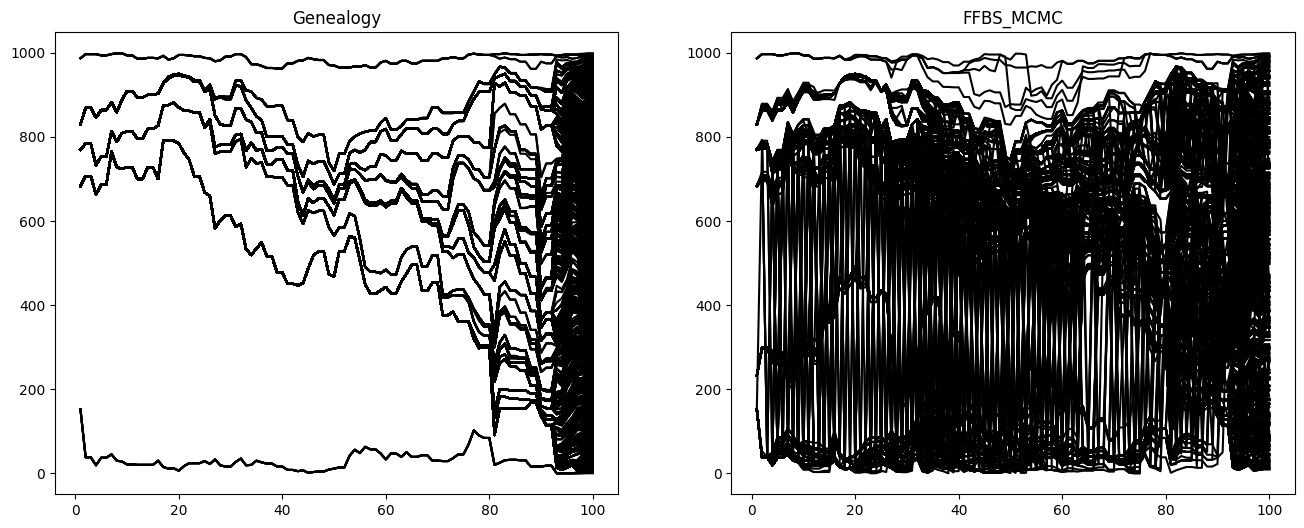

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i in range(N_genealogy):
    axes[0].plot(np.arange(1, fk.T+1, dtype=np.float64), Bs[:, i], c='black')
    axes[1].plot(np.arange(1, fk.T+1, dtype=np.float64), Bs_mcmc[:, i], c='black')
    
axes[0].set_title('Genealogy')
axes[1].set_title('FFBS_MCMC')
plt.show()

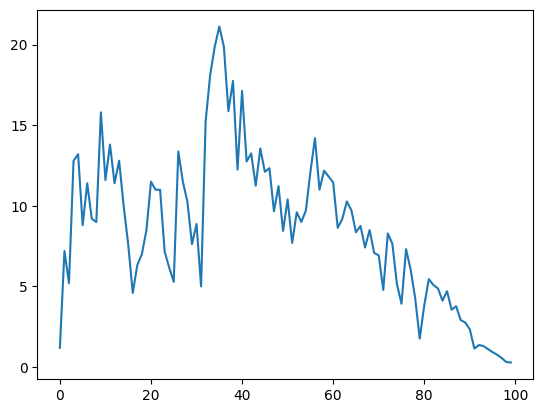

In [97]:
n_particles_ratios = [np.unique(Bs_mcmc[idx]).shape[0]/np.unique(Bs[idx]).shape[0] for idx in range(T)]
plt.plot(n_particles_ratios)